Biometrich Technologies and Behavioural Security
# **<center>Tutorial - Face Recognition</center>**
## **<center>EigenFace</center>**



## Step 1: Load data and packages in your VM

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
import numpy as np

In [ ]:
# Load data
lfw_dataset = fetch_lfw_people(min_faces_per_person=100)

_, h, w = lfw_dataset.images.shape
X = lfw_dataset.data
y = lfw_dataset.target
target_names = lfw_dataset.target_names

# split into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Step 2: Feature Extraction

In [ ]:
# Compute a PCA
n_components = 100
pca = PCA(n_components=n_components, whiten=True).fit(X_train)

# apply PCA transformation
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_train_pca))
print(np.shape(X_test_pca))

(798, 2914)
(342, 2914)
(798, 100)
(342, 100)


## Step 3: Classification with SVM

In [ ]:
#Train the SVM classifier

from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0, tol=1e-5)
clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=0, tol=1e-05)

In [ ]:
#Predict test labels and accuracy

y_pred = clf.predict(X_test)
from sklearn.metrics import accuracy_score
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_test, y_pred)*100)
print(acc)

Total Accuracy: 83.04 %


In [ ]:
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Colin Powell       0.74      0.82      0.78        73
  Donald Rumsfeld       0.83      0.81      0.82        36
    George W Bush       0.88      0.89      0.89       152
Gerhard Schroeder       0.71      0.83      0.77        30
       Tony Blair       0.94      0.67      0.78        51

         accuracy                           0.83       342
        macro avg       0.82      0.80      0.81       342
     weighted avg       0.84      0.83      0.83       342



['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


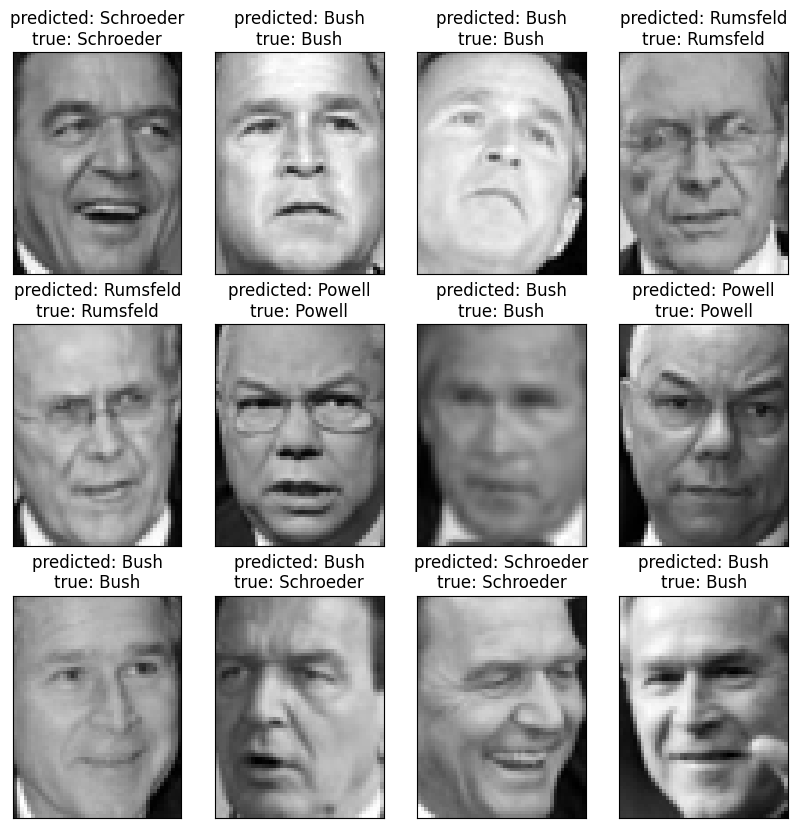

In [ ]:
print(target_names)
# Visualization
def plot_gallery(images, titles, h, w, rows=3, cols=4):
    f = plt.figure(figsize=(10,10))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i])
        plt.xticks(())
        plt.yticks(())

def titles(y_pred, y_test, target_names):
    predictions = []
    for i in range(y_pred.shape[0]):
        pred_name = target_names[y_pred[i]].split(' ')[-1]
        true_name = target_names[y_test[i]].split(' ')[-1]
        predictions.append('predicted: {0}\ntrue: {1}'.format(pred_name, true_name))
    return predictions

prediction_titles = list(titles(y_pred, y_test, target_names))
plot_gallery(X_test, prediction_titles, h, w)